In [1]:
# 1️ Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [2]:
# 2️ Load Dataset
df = pd.read_csv("pipline3.csv")
print("Dataset loaded successfully!")
print(df.head())
print(df.info())

Dataset loaded successfully!
   Unnamed: 0       age  hypertension  heart_disease       bmi  HbA1c_level  \
0        9065  1.000000             0              0  0.208314     0.090909   
1       22396  1.000000             1              0  0.381653     0.400000   
2       41915  0.712212             0              0  0.353862     0.454545   
3       30911  0.812312             1              0  0.233396     0.600000   
4       32402  0.000000             0              0  0.039802     0.272727   

   blood_glucose_level  diabetes  bmi_category  age_group  \
0             0.022727         0             3          4   
1             0.272727         1             4          4   
2             0.045455         0             4          3   
3             0.359091         1             4          3   
4             0.022727         0             1          1   

   htn_heart_interaction  gender_Female  gender_Male  gender_Other  \
0                      0              0            1       

In [3]:
# 3️ Handle Missing Values (if any)
print("\nMissing values per column:\n", df.isnull().sum())
df = df.dropna()   # Or use df.fillna(df.mean()) if needed



Missing values per column:
 Unnamed: 0                     0
age                            0
hypertension                   0
heart_disease                  0
bmi                            0
HbA1c_level                    0
blood_glucose_level            0
diabetes                       0
bmi_category                   0
age_group                      0
htn_heart_interaction          0
gender_Female                  0
gender_Male                    0
gender_Other                   0
smoking_history_No Info        0
smoking_history_current        0
smoking_history_ever           0
smoking_history_former         0
smoking_history_never          0
smoking_history_not current    0
dtype: int64


In [4]:
# 4️ Encode Categorical Columns (if present)
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [5]:
# 5️ Define Features (X) and Target (y)
X = df.drop(columns=['diabetes'])  
y = df['diabetes']


In [6]:
# 6️ Split Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# 7️ Standardize Feature Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 8️ Build Base SVM Model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)


SVC(random_state=42)

In [9]:
# 9️ Evaluate Base Model
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report


svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)


y_pred = svm_model.predict(X_test_scaled)

print("\n🔹 Base Model Evaluation 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



🔹 Base Model Evaluation 🔹
Accuracy: 0.8862363689949897
F1 Score: 0.8862363492314032

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89      1697
           1       0.89      0.89      0.89      1696

    accuracy                           0.89      3393
   macro avg       0.89      0.89      0.89      3393
weighted avg       0.89      0.89      0.89      3393



In [10]:
# 10️ Hyperparameter Tuning using GridSearchCV
param_grid = {
    'C': [1,10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(random_state=42),
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=2,
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=2)

In [11]:
# 11️ Evaluate Tuned Model
best_svm = grid_search.best_estimator_
y_pred_tuned = best_svm.predict(X_test_scaled)

print("\n🔹 Tuned Model Evaluation 🔹")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))



🔹 Tuned Model Evaluation 🔹
Accuracy: 0.8912466843501327
F1 Score: 0.8912462875923671

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89      1697
           1       0.89      0.89      0.89      1696

    accuracy                           0.89      3393
   macro avg       0.89      0.89      0.89      3393
weighted avg       0.89      0.89      0.89      3393



In [12]:
# 12️ k-Fold Cross Validation (Model Validation)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_svm, X, y, cv=kfold, scoring='accuracy')
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())



Cross-Validation Scores: [0.49307398 0.49130563 0.48747421 0.49513705 0.49204009]
Mean CV Accuracy: 0.49180619157644206


In [13]:
# 13️ Performance Comparison Summary
comparison = pd.DataFrame({
    "Model": ["Base SVM", "Tuned SVM"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_tuned)],
    "F1 Score": [f1_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred_tuned, average='weighted')]
})

print("\n Model Comparison Summary")
print(comparison)



 Model Comparison Summary
       Model  Accuracy  F1 Score
0   Base SVM  0.886236  0.886236
1  Tuned SVM  0.891247  0.891246


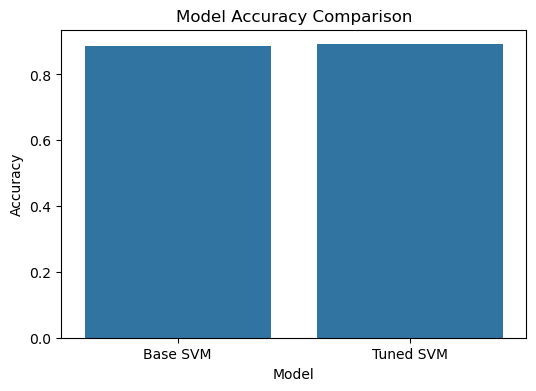

In [14]:
# 14️ Visualize Comparison
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.title("Model Accuracy Comparison")
plt.show()
